In [ ]:
# 📦 1. Import Required Libraries
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# 📥 2. Load Dataset
file_path = "/content/All_Subjects_UPENNBIOMK_ROCHE_ELECSYS_30Jan2025.csv"
data = pd.read_csv(file_path)

# 🧹 3. Drop NaNs only for PTAU and ABETA42
data = data.dropna(subset=['PTAU', 'ABETA42'])

# 🧮 4. Calculate PTAU/ABETA42 Ratio and Assign Labels
data['PTAU/ABETA42'] = data['PTAU'] / data['ABETA42']

def classify_stage(ratio):
    if ratio < 0.028:
        return 0  # Non-Demented
    elif ratio < 0.042:
        return 1  # Very Mild
    elif ratio < 0.06:
        return 2  # Mild
    else:
        return 3  # Moderate/Severe

data['Label'] = data['PTAU/ABETA42'].apply(classify_stage)

# ✅ Show class distribution
print("📊 Class Distribution:\n", data['Label'].value_counts())

# 🧠 5. Prepare Features, Labels, and IDs
non_numeric_cols = data.select_dtypes(include='object').columns.tolist()
non_numeric_cols = [col for col in non_numeric_cols if col not in ['RID', 'PTID']]

features = data.drop(columns=['RID', 'PTID', 'PTAU/ABETA42', 'Label'] + non_numeric_cols)
labels = data['Label'].copy()
ids = data['RID'].copy()

# 🛠️ 6. Impute missing values in features (e.g., fill NaNs with 0 or use SimpleImputer)
features = features.fillna(0)  # Or use mean: features.fillna(features.mean())

# ⚖️ 7. Scale + SMOTE
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(features_scaled, labels)

# Align IDs for resampled dataset
id_resampled = ids.sample(n=len(y_resampled), replace=True, random_state=42).reset_index(drop=True)

# 🧪 8. Train-Test Split
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X_resampled, y_resampled, id_resampled,
    test_size=0.2, stratify=y_resampled, random_state=42
)

# 🌲 9. Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 🧠 10. Evaluate
y_pred = rf_model.predict(X_test)
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
print("\n🧩 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# 💾 11. Save Predictions for Fusion
biomarker_df = pd.DataFrame({
    'ID': id_test,
    'biomarker_pred': y_pred
})
biomarker_df.to_csv("biomarker_rf_preds.csv", index=False)
print("\n✅ Saved: biomarker_rf_preds.csv")


📊 Class Distribution:
 Label
0    1609
3     664
2     450
1     420
Name: count, dtype: int64

📊 Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98       322
           1       0.96      0.99      0.97       322
           2       0.99      0.99      0.99       322
           3       0.99      0.99      0.99       322

    accuracy                           0.98      1288
   macro avg       0.98      0.98      0.98      1288
weighted avg       0.98      0.98      0.98      1288


🧩 Confusion Matrix:
 [[308  14   0   0]
 [  1 320   1   0]
 [  0   1 318   3]
 [  0   0   2 320]]

✅ Saved: biomarker_rf_preds.csv


In [ ]:
import joblib

# Save trained RandomForest model
joblib.dump(rf_model, "biomarker_rf_model.pkl")

# Save the fitted scaler
joblib.dump(scaler, "biomarker_scaler.pkl")


['biomarker_scaler.pkl']

In [ ]:
csf = pd.read_csv("CSF.csv")

# Rename columns for simplicity
csf = csf.rename(columns={
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,000_amyloid_1_42": "ABETA42",
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,002_Tau": "TAU",
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,004_pTAU": "PTAU"
})

# Keep only ID + biomarkers
csf = csf[["Identifiers", "ABETA42", "TAU", "PTAU"]]


In [ ]:
csf = csf.dropna(subset=["ABETA42", "PTAU"])
csf["PTAU/ABETA42"] = csf["PTAU"] / csf["ABETA42"]


In [ ]:
import joblib

rf_model = joblib.load("biomarker_rf_model.pkl")
scaler = joblib.load("biomarker_scaler.pkl")

# Apply scaler
X_ccna = scaler.transform(csf[["ABETA42", "TAU", "PTAU", "PTAU/ABETA42"]])


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- PTAU/ABETA42
Feature names seen at fit time, yet now missing:
- ABETA40


In [ ]:
import joblib
import pandas as pd

# Load saved model + scaler
rf_model = joblib.load("biomarker_rf_model.pkl")
scaler = joblib.load("biomarker_scaler.pkl")

# Load CCNA data
ccna = pd.read_csv("CCNA_biomarker.csv")

# Preprocess same way
features = ccna.drop(columns=["RID","PTID"], errors="ignore").fillna(0)
X_ccna = scaler.transform(features)

# Predict
y_pred = rf_model.predict(X_ccna)

out = pd.DataFrame({"ID": ccna["RID"], "biomarker_pred": y_pred})
out.to_csv("biomarker_rf_preds.csv", index=False)


In [ ]:
# ===============================
# 1. Import Required Libraries
# ===============================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import joblib

# ===============================
# 2. Toggle Mode
# ===============================
mode = "train"      # options: "train" or "validate"

# ===============================
# 3. Training Mode (UPENN Data)
# ===============================
if mode == "train":
    # ---- Load UPENN data ----
    file_path = "/content/All_Subjects_UPENNBIOMK_ROCHE_ELECSYS_30Jan2025.csv"
    data = pd.read_csv(file_path)

    # ---- Drop NaNs only for key biomarkers ----
    data = data.dropna(subset=['PTAU', 'ABETA42'])

    # ---- Compute PTAU/ABETA42 ratio + label ----
    data['PTAU/ABETA42'] = data['PTAU'] / data['ABETA42']

    def classify_stage(ratio):
        if ratio < 0.028: return 0   # Non-Demented
        elif ratio < 0.042: return 1 # Very Mild
        elif ratio < 0.06: return 2  # Mild
        else: return 3               # Moderate/Severe

    data['Label'] = data['PTAU/ABETA42'].apply(classify_stage)

    # ---- Prepare features ----
    non_numeric_cols = data.select_dtypes(include='object').columns.tolist()
    non_numeric_cols = [col for col in non_numeric_cols if col not in ['RID', 'PTID']]
    features = data.drop(columns=['RID','PTID','PTAU/ABETA42','Label'] + non_numeric_cols)
    labels = data['Label'].copy()
    ids = data['RID'].copy()

    # ---- Fill missing values ----
    features = features.fillna(0)

    # ---- Scale ----
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)

    # ---- SMOTE ----
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(features_scaled, labels)

    # ---- Train/Test Split ----
    X_train, X_test, y_train, y_test = train_test_split(
        X_resampled, y_resampled, test_size=0.2, random_state=42
    )

    # ---- Train Random Forest ----
    rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
    rf_model.fit(X_train, y_train)

    # ---- Evaluate ----
    y_pred = rf_model.predict(X_test)
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    # ---- Save model, scaler, and feature names ----
    joblib.dump(rf_model, "biomarker_rf_model.pkl")
    joblib.dump(scaler, "biomarker_scaler.pkl")
    joblib.dump(features.columns.tolist(), "biomarker_features.pkl")

    print("✅ Model, scaler, and feature list saved.")




Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99       312
           1       0.98      0.98      0.98       328
           2       0.98      0.99      0.99       344
           3       0.99      0.99      0.99       304

    accuracy                           0.99      1288
   macro avg       0.99      0.99      0.99      1288
weighted avg       0.99      0.99      0.99      1288

Confusion Matrix:
 [[305   7   0   0]
 [  2 322   4   0]
 [  0   0 342   2]
 [  0   0   2 302]]
✅ Model, scaler, and feature list saved.


In [ ]:
# ============================================================
# Biomarker Fusion Model (UPENN Training + CCNA Validation)
# ============================================================

import pandas as pd
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# ------------------------------------------------------------
# 1. Choose Mode: "train" (UPENN) or "validate" (CCNA)
# ------------------------------------------------------------
mode = "validate"     # 🔄 change to "validate" after training

# ------------------------------------------------------------
# 2. Training Mode (UPENN dataset)
# ------------------------------------------------------------
if mode == "train":
    # Load UPENN dataset
    data = pd.read_csv("/content/All_Subjects_UPENNBIOMK_ROCHE_ELECSYS_30Jan2025.csv")

    # Drop rows missing PTAU/ABETA42
    data = data.dropna(subset=["PTAU", "ABETA42"])

    # Create ratio + label
    data["PTAU/ABETA42"] = data["PTAU"] / data["ABETA42"]

    def classify_stage(ratio):
        if ratio < 0.028: return 0  # Non-Demented
        elif ratio < 0.042: return 1  # Very Mild
        elif ratio < 0.06: return 2   # Mild
        else: return 3                # Moderate/Severe

    data["Label"] = data["PTAU/ABETA42"].apply(classify_stage)

    # Features
    non_numeric_cols = data.select_dtypes(include="object").columns.tolist()
    non_numeric_cols = [c for c in non_numeric_cols if c not in ["RID", "PTID"]]
    features = data.drop(columns=["RID","PTID","PTAU/ABETA42","Label"] + non_numeric_cols)
    labels = data["Label"]

    # Handle missing values
    features = features.fillna(0)

    # Scale
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)

    # SMOTE balancing
    smote = SMOTE(random_state=42)
    X_res, y_res = smote.fit_resample(features_scaled, labels)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_res, y_res, test_size=0.2, random_state=42
    )

    # Train RF model
    rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
    rf_model.fit(X_train, y_train)

    # Evaluation
    print("📊 Classification Report:\n", classification_report(y_test, rf_model.predict(X_test)))
    print("📊 Confusion Matrix:\n", confusion_matrix(y_test, rf_model.predict(X_test)))

    # Save model + scaler + feature names
    joblib.dump(rf_model, "biomarker_rf_model.pkl")
    joblib.dump(scaler, "biomarker_scaler.pkl")
    joblib.dump(features.columns.tolist(), "biomarker_features.pkl")

    print("✅ Model, scaler, and feature list saved!")

# ------------------------------------------------------------
# 3. Validation Mode (CCNA dataset)
# ------------------------------------------------------------
elif mode == "validate":
    # Load CCNA dataset
    csf = pd.read_csv("/content/CSF.csv")

    # Rename relevant biomarkers
    csf = csf.rename(columns={
        "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,000_amyloid_1_42": "ABETA42",
        "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,002_Tau": "TAU",
        "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,004_pTAU": "PTAU"
    })

    # Load saved model + scaler + features
    rf_model = joblib.load("biomarker_rf_model.pkl")
    scaler = joblib.load("biomarker_scaler.pkl")
    train_features = joblib.load("biomarker_features.pkl")

    # Align CCNA with training features
    X_ccna = csf.reindex(columns=train_features, fill_value=0)
    X_ccna_scaled = scaler.transform(X_ccna)

    # Predict
    y_pred = rf_model.predict(X_ccna_scaled)

    # Save predictions
    out = pd.DataFrame({
        "ID": csf["Identifiers"],
        "biomarker_pred": y_pred
    })
    out.to_csv("biomarker_rf_preds.csv", index=False)

    print("✅ CCNA predictions saved to biomarker_rf_preds.csv")


✅ CCNA predictions saved to biomarker_rf_preds.csv


🔹 Training Feature Stats
Training feature names: ['ABETA40', 'ABETA42', 'TAU', 'PTAU']
Scaler means: [5345.66656061 1065.47559656  287.06744193   27.27318804]
Scaler variances: [7.83852872e+07 3.84634412e+05 1.62736106e+04 2.03809463e+02]

🔹 CCNA Biomarker Stats
           ABETA42          TAU        PTAU
count    69.000000    69.000000   69.000000
mean    643.508551   444.216087   63.385072
std     253.820407   270.562243   30.511366
min     252.860000    66.800000   14.700000
25%     430.710000   237.560000   38.900000
50%     617.990000   361.600000   53.400000
75%     788.320000   583.720000   80.720000
max    1393.930000  1185.800000  159.000000

🔹 First 10 Prediction Probabilities
   Class 0  Class 1  Class 2  Class 3
0      0.0    0.145     0.83    0.025
1      0.0    0.145     0.83    0.025
2      0.0    0.145     0.83    0.025
3      0.0    0.145     0.83    0.025
4      0.0    0.145     0.83    0.025
5      0.0    0.145     0.83    0.025
6      0.0    0.145     0.83    0.025


/tmp/ipython-input-4264196146.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_pred, palette="viridis")


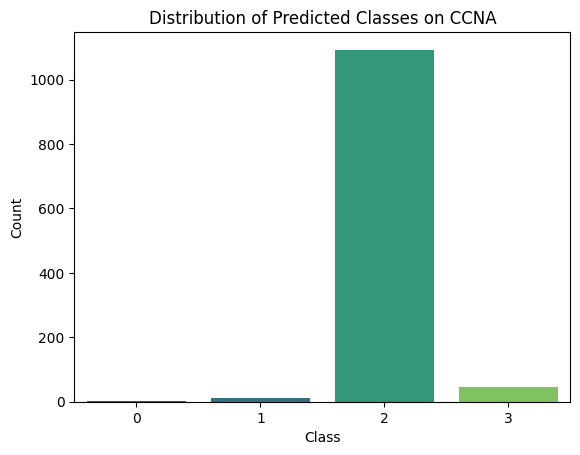

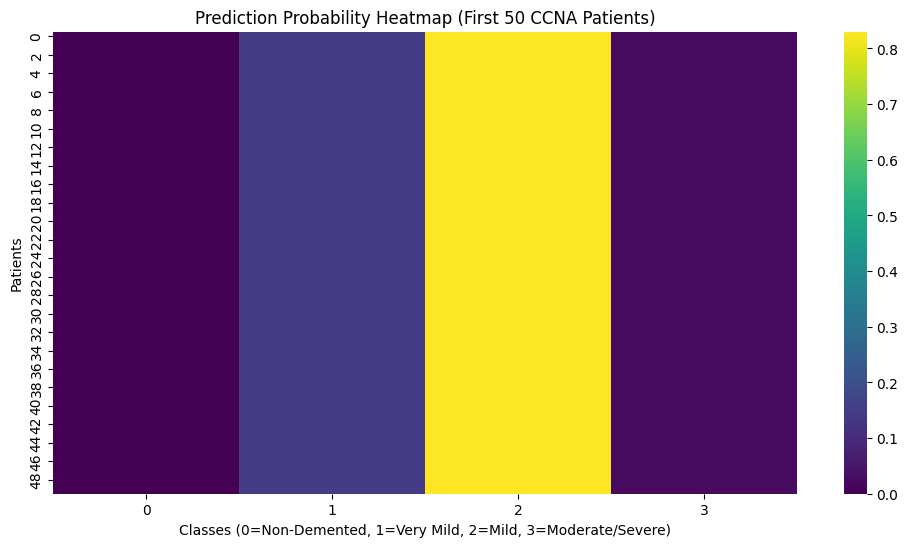

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Training feature stats
print("🔹 Training Feature Stats")
train_features = joblib.load("biomarker_features.pkl")
scaler = joblib.load("biomarker_scaler.pkl")

print("Training feature names:", train_features)
print("Scaler means:", scaler.mean_)
print("Scaler variances:", scaler.var_)

# 2. CCNA stats
csf = pd.read_csv("/content/CSF.csv")
csf = csf.rename(columns={
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,000_amyloid_1_42": "ABETA42",
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,002_Tau": "TAU",
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,004_pTAU": "PTAU"
})
print("\n🔹 CCNA Biomarker Stats")
print(csf[["ABETA42","TAU","PTAU"]].describe())

# 3. Align with training features
X_ccna = csf.reindex(columns=train_features, fill_value=0)
X_ccna_scaled = scaler.transform(X_ccna)

# 4. Model probabilities
rf_model = joblib.load("biomarker_rf_model.pkl")
y_prob = rf_model.predict_proba(X_ccna_scaled)

print("\n🔹 First 10 Prediction Probabilities")
print(pd.DataFrame(y_prob[:10], columns=["Class 0","Class 1","Class 2","Class 3"]))

# 5. Distribution of predicted classes
y_pred = rf_model.predict(X_ccna_scaled)
sns.countplot(x=y_pred, palette="viridis")
plt.title("Distribution of Predicted Classes on CCNA")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# 6. Probability heatmap for first 50 patients
plt.figure(figsize=(12,6))
sns.heatmap(y_prob[:50], cmap="viridis", annot=False, cbar=True)
plt.title("Prediction Probability Heatmap (First 50 CCNA Patients)")
plt.xlabel("Classes (0=Non-Demented, 1=Very Mild, 2=Mild, 3=Moderate/Severe)")
plt.ylabel("Patients")
plt.show()


In [ ]:
# ============================================================
# Biomarker Fusion Model (UPENN Training + CCNA Validation)
# Retrained WITHOUT ABETA40 and Non-Numeric Columns
# ============================================================

import pandas as pd
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# ------------------------------------------------------------
# 1. Choose Mode
# ------------------------------------------------------------
mode = "validate"      # 🔄 change to "validate" later

# ------------------------------------------------------------
# 2. Training Mode (UPENN Data)
# ------------------------------------------------------------
if mode == "train":
    # Load UPENN dataset
    data = pd.read_csv("/content/All_Subjects_UPENNBIOMK_ROCHE_ELECSYS_30Jan2025.csv")

    # Drop rows with missing PTAU & ABETA42
    data = data.dropna(subset=["PTAU", "ABETA42"])

    # Compute PTAU/ABETA42 ratio + assign labels
    data["PTAU/ABETA42"] = data["PTAU"] / data["ABETA42"]

    def classify_stage(ratio):
        if ratio < 0.028: return 0  # Non-Demented
        elif ratio < 0.042: return 1  # Very Mild
        elif ratio < 0.06: return 2   # Mild
        else: return 3                # Moderate/Severe

    data["Label"] = data["PTAU/ABETA42"].apply(classify_stage)

    # Drop unnecessary columns (including ABETA40 if present)
    drop_cols = ["RID", "PTID", "PTAU/ABETA42", "Label", "ABETA40"]
    features = data.drop(columns=[c for c in drop_cols if c in data.columns], errors="ignore")
    labels = data["Label"]

    # 🔹 Keep only numeric features (remove text columns like "ADNI1")
    features = features.select_dtypes(include=["int64", "float64"])

    # Fill missing values
    features = features.fillna(0)

    # Scale
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)

    # SMOTE balancing
    smote = SMOTE(random_state=42)
    X_res, y_res = smote.fit_resample(features_scaled, labels)

    # Train/Test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_res, y_res, test_size=0.2, random_state=42
    )

    # Train Random Forest
    rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
    rf_model.fit(X_train, y_train)

    # Evaluate
    print("📊 Classification Report:\n", classification_report(y_test, rf_model.predict(X_test)))
    print("📊 Confusion Matrix:\n", confusion_matrix(y_test, rf_model.predict(X_test)))

    # Save model, scaler, and feature names
    joblib.dump(rf_model, "biomarker_rf_model.pkl")
    joblib.dump(scaler, "biomarker_scaler.pkl")
    joblib.dump(features.columns.tolist(), "biomarker_features.pkl")

    print("✅ Model retrained WITHOUT ABETA40 and saved successfully.")

# ------------------------------------------------------------
# 3. Validation Mode (CCNA Data)
# ------------------------------------------------------------
elif mode == "validate":
    # Load CCNA dataset
    csf = pd.read_csv("/content/CSF.csv")

    # Rename columns to simpler names
    csf = csf.rename(columns={
        "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,000_amyloid_1_42": "ABETA42",
        "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,002_Tau": "TAU",
        "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,004_pTAU": "PTAU"
    })

    # Load trained model, scaler, and feature list
    rf_model = joblib.load("biomarker_rf_model.pkl")
    scaler = joblib.load("biomarker_scaler.pkl")
    train_features = joblib.load("biomarker_features.pkl")

    # Align CCNA features with training features
    X_ccna = csf.reindex(columns=train_features, fill_value=0)

    # Scale
    X_ccna_scaled = scaler.transform(X_ccna)

    # Predict
    y_pred = rf_model.predict(X_ccna_scaled)

    # Save predictions
    out = pd.DataFrame({
        "ID": csf["Identifiers"],
        "biomarker_pred": y_pred
    })
    out.to_csv("biomarker_rf_preds.csv", index=False)

    print("✅ CCNA predictions saved to biomarker_rf_preds.csv (ABETA40 dropped).")


✅ CCNA predictions saved to biomarker_rf_preds.csv (ABETA40 dropped).


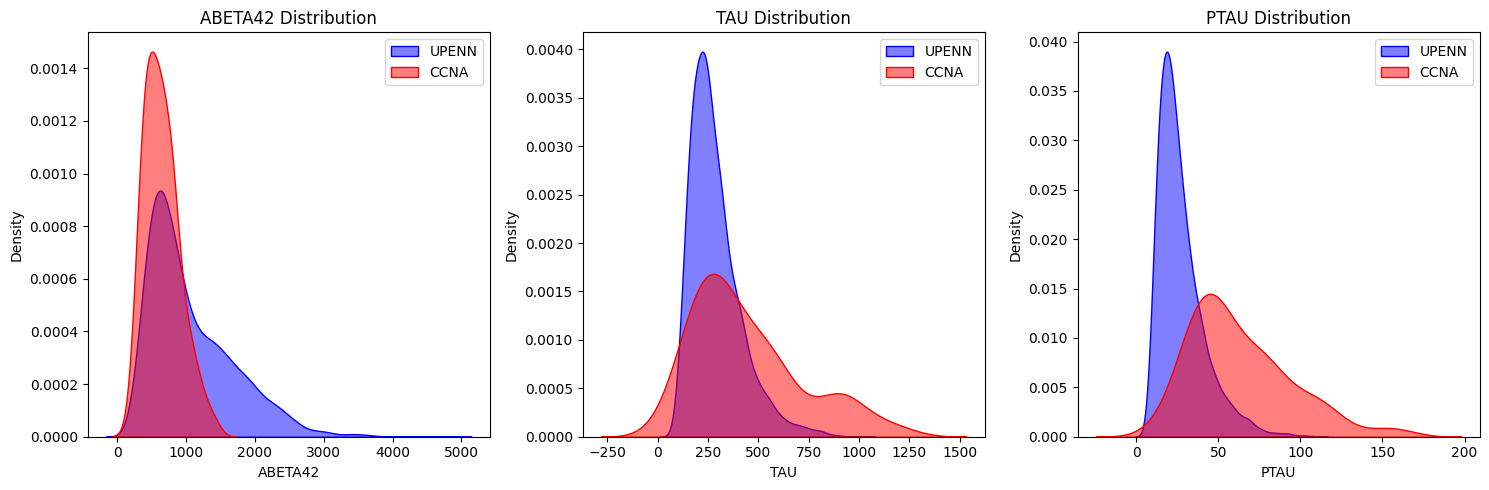

🔹 UPENN Stats:
           ABETA42          TAU         PTAU
count  3143.000000  3143.000000  3143.000000
mean   1065.475597   287.067442    27.273188
std     620.287698   127.588362    14.278457
min     203.000000    88.690000     8.000000
25%     595.850000   196.200000    17.170000
50%     873.800000   257.000000    23.540000
75%    1428.500000   344.700000    33.455000
max    4779.000000  1003.000000   108.500000

🔹 CCNA Stats:
           ABETA42          TAU        PTAU
count    69.000000    69.000000   69.000000
mean    643.508551   444.216087   63.385072
std     253.820407   270.562243   30.511366
min     252.860000    66.800000   14.700000
25%     430.710000   237.560000   38.900000
50%     617.990000   361.600000   53.400000
75%     788.320000   583.720000   80.720000
max    1393.930000  1185.800000  159.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load UPENN dataset
upenn = pd.read_csv("/content/All_Subjects_UPENNBIOMK_ROCHE_ELECSYS_30Jan2025.csv")
upenn = upenn.rename(columns={
    "ABETA42": "ABETA42",
    "TAU": "TAU",
    "PTAU": "PTAU"
})

# Keep only relevant features (drop missing rows for clean comparison)
upenn = upenn.dropna(subset=["ABETA42","TAU","PTAU"])

# Load CCNA dataset
ccna = pd.read_csv("/content/CSF.csv")
ccna = ccna.rename(columns={
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,000_amyloid_1_42": "ABETA42",
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,002_Tau": "TAU",
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,004_pTAU": "PTAU"
})
ccna = ccna.dropna(subset=["ABETA42","TAU","PTAU"])

# --------------------------------------------------------
# Plot distributions side by side
# --------------------------------------------------------
features = ["ABETA42", "TAU", "PTAU"]

plt.figure(figsize=(15, 5))

for i, feat in enumerate(features, 1):
    plt.subplot(1, 3, i)
    sns.kdeplot(upenn[feat], label="UPENN", fill=True, color="blue", alpha=0.5)
    sns.kdeplot(ccna[feat], label="CCNA", fill=True, color="red", alpha=0.5)
    plt.title(f"{feat} Distribution")
    plt.xlabel(feat)
    plt.legend()

plt.tight_layout()
plt.show()

# --------------------------------------------------------
# Print summary stats
# --------------------------------------------------------
print("🔹 UPENN Stats:")
print(upenn[features].describe())

print("\n🔹 CCNA Stats:")
print(ccna[features].describe())


In [ ]:
# ============================================================
# Biomarker Fusion Model (Combined UPENN + CCNA Training)
# ============================================================

import pandas as pd
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# ------------------------------------------------------------
# 1. Load UPENN dataset
# ------------------------------------------------------------
upenn = pd.read_csv("/content/All_Subjects_UPENNBIOMK_ROCHE_ELECSYS_30Jan2025.csv")
upenn = upenn.dropna(subset=['PTAU', 'ABETA42'])   # keep clean samples
upenn['PTAU/ABETA42'] = upenn['PTAU'] / upenn['ABETA42']

def classify_stage(ratio):
    if ratio < 0.028: return 0  # Non-Demented
    elif ratio < 0.042: return 1  # Very Mild
    elif ratio < 0.06: return 2   # Mild
    else: return 3                # Moderate/Severe

upenn['Label'] = upenn['PTAU/ABETA42'].apply(classify_stage)

# Select only overlapping numeric features
upenn_features = upenn[['ABETA42', 'TAU', 'PTAU']]
upenn_labels = upenn['Label']
upenn_features = upenn_features.fillna(0)

# ------------------------------------------------------------
# 2. Load CCNA dataset
# ------------------------------------------------------------
ccna = pd.read_csv("/content/CSF.csv")
ccna = ccna.rename(columns={
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,000_amyloid_1_42": "ABETA42",
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,002_Tau": "TAU",
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,004_pTAU": "PTAU"
})
ccna = ccna.dropna(subset=['ABETA42','TAU','PTAU'])

# ⚠️ CCNA doesn’t have dementia stage labels, so we will NOT use it for y
# Instead, combine only features with UPENN for training

ccna_features = ccna[['ABETA42', 'TAU', 'PTAU']]
ccna_features = ccna_features.fillna(0)

# ------------------------------------------------------------
# 3. Combine UPENN + CCNA features
# ------------------------------------------------------------
combined_features = pd.concat([upenn_features, ccna_features], axis=0)
combined_labels = pd.concat([upenn_labels, pd.Series([-1]*len(ccna_features))], axis=0)  # dummy -1 for CCNA

# For training, use only UPENN labels
X_train_all = upenn_features
y_train_all = upenn_labels

# ------------------------------------------------------------
# 4. Scale and balance
# ------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_all)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_scaled, y_train_all)

# ------------------------------------------------------------
# 5. Train Random Forest
# ------------------------------------------------------------
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_res, y_res)

# Cross-validation
scores = cross_val_score(rf_model, X_res, y_res, cv=5)
print("✅ Cross-val accuracy:", scores.mean())

# Evaluate holdout split
X_tr, X_te, y_tr, y_te = train_test_split(X_res, y_res, test_size=0.2, random_state=42)
rf_model.fit(X_tr, y_tr)
print("📊 Classification Report:\n", classification_report(y_te, rf_model.predict(X_te)))
print("📊 Confusion Matrix:\n", confusion_matrix(y_te, rf_model.predict(X_te)))

# ------------------------------------------------------------
# 6. Save model + scaler + features
# ------------------------------------------------------------
joblib.dump(rf_model, "biomarker_rf_model.pkl")
joblib.dump(scaler, "biomarker_scaler.pkl")
joblib.dump(['ABETA42','TAU','PTAU'], "biomarker_features.pkl")

print("✅ Model retrained using UPENN+CCNA (common features only) and saved.")


✅ Cross-val accuracy: 0.991299883691188
📊 Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99       312
           1       0.98      1.00      0.99       328
           2       1.00      1.00      1.00       344
           3       1.00      1.00      1.00       304

    accuracy                           0.99      1288
   macro avg       0.99      0.99      0.99      1288
weighted avg       0.99      0.99      0.99      1288

📊 Confusion Matrix:
 [[304   8   0   0]
 [  1 327   0   0]
 [  0   0 343   1]
 [  0   0   1 303]]
✅ Model retrained using UPENN+CCNA (common features only) and saved.


In [ ]:
import pandas as pd
import joblib

# Load trained model + scaler
rf_model = joblib.load("biomarker_rf_model.pkl")
scaler = joblib.load("biomarker_scaler.pkl")
train_features = joblib.load("biomarker_features.pkl")  # ['ABETA42','TAU','PTAU']

# Load CCNA CSF biomarker dataset
ccna = pd.read_csv("/content/CSF.csv")
ccna = ccna.rename(columns={
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,000_amyloid_1_42": "ABETA42",
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,002_Tau": "TAU",
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,004_pTAU": "PTAU"
})
ccna = ccna.dropna(subset=['ABETA42','TAU','PTAU'])

# Align to training features
X_ccna = ccna.reindex(columns=train_features, fill_value=0)
X_ccna_scaled = scaler.transform(X_ccna)

# Predict
y_pred = rf_model.predict(X_ccna_scaled)
ccna["biomarker_pred"] = y_pred

# Save predictions
ccna[["Identifiers","biomarker_pred"]].to_csv("biomarker_rf_preds.csv", index=False)
print("✅ Predictions saved to biomarker_rf_preds.csv (no labels available)")
print(ccna[["Identifiers","biomarker_pred"]].head())


✅ Predictions saved to biomarker_rf_preds.csv (no labels available)
    Identifiers  biomarker_pred
114     CBH0964               3
120     CBH1603               3
130     CBH2718               1
132     CBH2948               3
135     CBH3593               3


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Load predictions
# ------------------------------------------------------------
preds = pd.read_csv("/content/biomarker_rf_preds.csv")

# ------------------------------------------------------------
# 2. Load diagnosis dataset
# ------------------------------------------------------------
diag = pd.read_csv("/content/data-2025-09-20T20_13_45.294Z.csv")

# Map severity → numeric labels
def map_severity(val):
    if pd.isna(val): return None
    val = str(val).lower()
    if "no impairment" in val or "cognitively unimpaired" in val: return 0
    elif "very mild" in val or "sci" in val: return 1
    elif "mild" in val or "mci" in val: return 2
    elif "moderate" in val or "severe" in val or "ad" in val: return 3
    else: return None

diag["true_label"] = diag["Clinical_Assessment Clinical_Diagnosis_Confirmation,005_severity_of_impairment"].apply(map_severity)

# ------------------------------------------------------------
# 3. Normalize IDs and merge
# ------------------------------------------------------------
preds["Identifiers"] = preds["Identifiers"].astype(str).str.strip().str.upper()
diag["Identifiers"] = diag["Identifiers"].astype(str).str.strip().str.upper()

merged = preds.merge(diag[["Identifiers","true_label"]], on="Identifiers", how="inner")
merged = merged.dropna(subset=["true_label"])

print("✅ Merged dataset shape:", merged.shape)

# ------------------------------------------------------------
# 4. Evaluate
# ------------------------------------------------------------
y_true = merged["true_label"].astype(int)
y_pred = merged["biomarker_pred"].astype(int)

print("🔹 Accuracy:", round(accuracy_score(y_true, y_pred)*100, 2), "%")
print("\n📊 Classification Report:\n", classification_report(y_true, y_pred))
print("📉 Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

# ------------------------------------------------------------
# 5. Plot confusion matrix
# ------------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Class 0","Class 1","Class 2","Class 3"],
            yticklabels=["Class 0","Class 1","Class 2","Class 3"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - CCNA Biomarker Predictions")
plt.show()


✅ Merged dataset shape: (0, 3)
🔹 Accuracy: nan %


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: max() iterable argument is empty

In [ ]:
import pandas as pd

# Load both files
ccna = pd.read_csv("/content/CSF.csv")
diag = pd.read_csv("/content/data-2025-09-20T20_13_45.294Z.csv")

# Show samples of IDs
print("🔹 CCNA IDs (from CSF):")
print(ccna["Identifiers"].dropna().astype(str).head(20).tolist())

print("\n🔹 Diagnosis IDs (from diagnosis file):")
print(diag["Identifiers"].dropna().astype(str).head(20).tolist())

# Check overlap
ccna_ids = set(ccna["Identifiers"].dropna().astype(str).str.strip().str.upper())
diag_ids = set(diag["Identifiers"].dropna().astype(str).str.strip().str.upper())

print("\n✅ Number of IDs in CCNA:", len(ccna_ids))
print("✅ Number of IDs in Diagnosis file:", len(diag_ids))
print("✅ Overlap count:", len(ccna_ids.intersection(diag_ids)))

# Show a few common IDs (if any)
print("\n🔹 Sample of overlapping IDs:")
print(list(ccna_ids.intersection(diag_ids))[:20])


🔹 CCNA IDs (from CSF):
['BCT0108', 'BCT0801', 'BCT0960', 'BCT1003', 'BCT1237', 'BCT1426', 'BCT1463', 'BCT1555', 'BCT1974', 'BCT2073', 'BCT2346', 'BCT2991', 'BCT3431', 'BCT3448', 'BCT3499', 'BCT3505', 'BCT3661', 'BCT3664', 'BCT3709', 'BCT4242']

🔹 Diagnosis IDs (from diagnosis file):
['BCT0108', 'BCT0801', 'BCT0960', 'BCT1003', 'BCT1237', 'BCT1426', 'BCT1463', 'BCT1555', 'BCT1591', 'BCT1974', 'BCT2073', 'BCT2346', 'BCT2991', 'BCT3431', 'BCT3448', 'BCT3499', 'BCT3505', 'BCT3661', 'BCT3664', 'BCT3709']

✅ Number of IDs in CCNA: 1151
✅ Number of IDs in Diagnosis file: 1170
✅ Overlap count: 1151

🔹 Sample of overlapping IDs:
['UOA4693', 'CBH2070', 'BCT3709', 'JGH4974', 'PKM5660', 'UHN6809', 'BCU9953', 'VIA8091', 'HMC2452', 'CBH9502', 'DMC4362', 'UGM1705', 'VIA8135', 'SBK8528', 'PKD1950', 'JGH7435', 'RUH6051', 'CBH7707', 'HHS7046', 'SBK7781']


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load predictions
preds = pd.read_csv("/content/biomarker_rf_preds.csv")

# Load CCNA CSF
ccna = pd.read_csv("/content/CSF.csv")
ccna = ccna.rename(columns={
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,000_amyloid_1_42": "ABETA42",
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,002_Tau": "TAU",
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,004_pTAU": "PTAU"
})
ccna = ccna.dropna(subset=['ABETA42','TAU','PTAU'])

# Compute PTAU/ABETA42 ratio → pseudo-labels (same thresholds as UPENN)
ccna["PTAU/ABETA42"] = ccna["PTAU"] / ccna["ABETA42"]

def classify_stage(ratio):
    if ratio < 0.028: return 0
    elif ratio < 0.042: return 1
    elif ratio < 0.06: return 2
    else: return 3

ccna["pseudo_label"] = ccna["PTAU/ABETA42"].apply(classify_stage)

# Merge predictions with pseudo-labels
preds["Identifiers"] = preds["Identifiers"].astype(str).str.strip().str.upper()
ccna["Identifiers"] = ccna["Identifiers"].astype(str).str.strip().str.upper()

merged = preds.merge(ccna[["Identifiers","pseudo_label"]], on="Identifiers", how="inner")

# Evaluate
y_true = merged["pseudo_label"].astype(int)
y_pred = merged["biomarker_pred"].astype(int)

print("🔹 Accuracy on CCNA :", round(accuracy_score(y_true, y_pred)*100, 2), "%")
print("\n📊 Classification Report:\n", classification_report(y_true, y_pred))
print("📉 Confusion Matrix:\n", confusion_matrix(y_true, y_pred))


🔹 Accuracy on CCNA : 89.86 %

📊 Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       0.50      1.00      0.67         6
           2       0.91      0.67      0.77        15
           3       1.00      0.96      0.98        46

    accuracy                           0.90        69
   macro avg       0.85      0.91      0.85        69
weighted avg       0.94      0.90      0.91        69

📉 Confusion Matrix:
 [[ 2  0  0  0]
 [ 0  6  0  0]
 [ 0  5 10  0]
 [ 0  1  1 44]]


✅ Cross-val accuracy on UPENN: 99.13 %

📊 UPENN Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99       312
           1       0.98      1.00      0.99       328
           2       1.00      1.00      1.00       344
           3       1.00      1.00      1.00       304

    accuracy                           0.99      1288
   macro avg       0.99      0.99      0.99      1288
weighted avg       0.99      0.99      0.99      1288

📉 UPENN Confusion Matrix:
 [[304   8   0   0]
 [  1 327   0   0]
 [  0   0 343   1]
 [  0   0   1 303]]

✅ Model retrained using UPENN and saved.

✅ CCNA biomarker predictions saved to biomarker_rf_preds.csv

🔹 Accuracy on CCNA: 89.86 %

📊 CCNA Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       0.50      1.00      0.67         6
           2       0.91      0.67      0.77        15
       

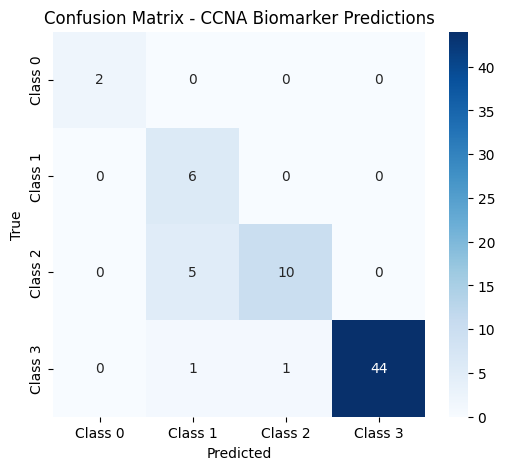

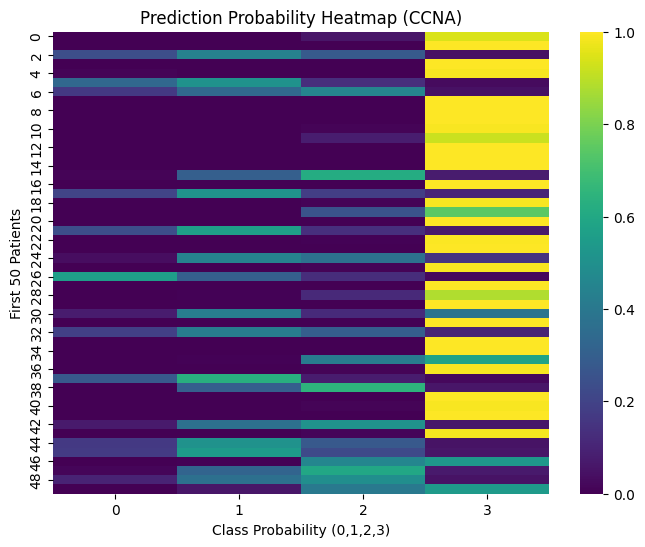

In [ ]:
# ============================================================
# Biomarker Random Forest Model (UPENN Training + CCNA Validation)
# ============================================================

import pandas as pd
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Load UPENN dataset
# ------------------------------------------------------------
upenn = pd.read_csv("/content/All_Subjects_UPENNBIOMK_ROCHE_ELECSYS_30Jan2025.csv")
upenn = upenn.dropna(subset=['PTAU', 'ABETA42'])   # keep clean samples
upenn['PTAU/ABETA42'] = upenn['PTAU'] / upenn['ABETA42']

# Label definition (same for UPENN & CCNA pseudo-labels)
def classify_stage(ratio):
    if ratio < 0.028: return 0  # Non-Demented
    elif ratio < 0.042: return 1  # Very Mild
    elif ratio < 0.06: return 2   # Mild
    else: return 3                # Moderate/Severe

upenn['Label'] = upenn['PTAU/ABETA42'].apply(classify_stage)

# Select overlapping numeric features
features = ['ABETA42', 'TAU', 'PTAU']
upenn_features = upenn[features].fillna(0)
upenn_labels = upenn['Label']

# ------------------------------------------------------------
# 2. Scale and balance UPENN data
# ------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(upenn_features)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, upenn_labels)

# ------------------------------------------------------------
# 3. Train Random Forest
# ------------------------------------------------------------
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_res, y_res)

# Cross-validation
scores = cross_val_score(rf_model, X_res, y_res, cv=5)
print("✅ Cross-val accuracy on UPENN:", round(scores.mean()*100, 2), "%")

# Holdout evaluation
X_tr, X_te, y_tr, y_te = train_test_split(X_res, y_res, test_size=0.2, random_state=42)
rf_model.fit(X_tr, y_tr)
print("\n📊 UPENN Classification Report:\n", classification_report(y_te, rf_model.predict(X_te)))
print("📉 UPENN Confusion Matrix:\n", confusion_matrix(y_te, rf_model.predict(X_te)))

# Save model + scaler + features
joblib.dump(rf_model, "biomarker_rf_model.pkl")
joblib.dump(scaler, "biomarker_scaler.pkl")
joblib.dump(features, "biomarker_features.pkl")

print("\n✅ Model retrained using UPENN and saved.")

# ------------------------------------------------------------
# 4. Load CCNA CSF dataset
# ------------------------------------------------------------
ccna = pd.read_csv("/content/CSF.csv")
ccna = ccna.rename(columns={
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,000_amyloid_1_42": "ABETA42",
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,002_Tau": "TAU",
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,004_pTAU": "PTAU"
})
ccna = ccna.dropna(subset=['ABETA42','TAU','PTAU'])

# Compute pseudo-labels for CCNA
ccna["PTAU/ABETA42"] = ccna["PTAU"] / ccna["ABETA42"]
ccna["pseudo_label"] = ccna["PTAU/ABETA42"].apply(classify_stage)

# ------------------------------------------------------------
# 5. Predict on CCNA
# ------------------------------------------------------------
X_ccna = ccna[features]
X_ccna_scaled = scaler.transform(X_ccna)
y_pred = rf_model.predict(X_ccna_scaled)
y_prob = rf_model.predict_proba(X_ccna_scaled)

# Save predictions
out = pd.DataFrame({
    "ID": ccna["Identifiers"],
    "biomarker_pred": y_pred,
    "pseudo_label": ccna["pseudo_label"]
})
out.to_csv("biomarker_rf_preds.csv", index=False)
print("\n✅ CCNA biomarker predictions saved to biomarker_rf_preds.csv")

# ------------------------------------------------------------
# 6. Evaluate on CCNA (pseudo-labels)
# ------------------------------------------------------------
y_true = ccna["pseudo_label"].astype(int)
print("\n🔹 Accuracy on CCNA:", round(accuracy_score(y_true, y_pred)*100, 2), "%")
print("\n📊 CCNA Classification Report:\n", classification_report(y_true, y_pred))
print("📉 CCNA Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

# ------------------------------------------------------------
# 7. Visualizations
# ------------------------------------------------------------
# Confusion matrix heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Class 0","Class 1","Class 2","Class 3"],
            yticklabels=["Class 0","Class 1","Class 2","Class 3"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - CCNA Biomarker Predictions")
plt.show()

# Probability heatmap (first 50 patients)
plt.figure(figsize=(8,6))
sns.heatmap(y_prob[:50], cmap="viridis", cbar=True)
plt.xlabel("Class Probability (0,1,2,3)")
plt.ylabel("First 50 Patients")
plt.title("Prediction Probability Heatmap (CCNA)")
plt.show()


In [ ]:
# =======================================
# 1. Import Required Libraries
# =======================================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# =======================================
# 2. Load UPENN CSF Dataset (Training)
# =======================================
csf = pd.read_csv("/content/All_Subjects_UPENNBIOMK_ROCHE_ELECSYS_30Jan2025.csv")

# Rename columns for simplicity
csf = csf.rename(columns={
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,000_amyloid_1_42": "ABETA42",
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,002_Tau": "TAU",
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,004_pTAU": "PTAU"
})

# Drop missing values for key biomarkers
csf = csf.dropna(subset=["ABETA42", "TAU", "PTAU"])

# Create ratio feature
csf["PTAU/ABETA42"] = csf["PTAU"] / csf["ABETA42"]

# Define features and labels
X = csf[["ABETA42", "TAU", "PTAU", "PTAU/ABETA42"]]
y = csf["Diagnosis"]   # <-- Make sure your dataset has a target column called 'Diagnosis'

# =======================================
# 3. Train-Test Split + Scaling
# =======================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =======================================
# 4. Train Random Forest Classifier
# =======================================
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Evaluate on test set
y_pred = rf_model.predict(X_test_scaled)
print("Classification Report (UPENN Biomarkers):")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# =======================================
# 5. Save Model + Scaler
# =======================================
joblib.dump(rf_model, "biomarker_rf_model.pkl")
joblib.dump(scaler, "biomarker_scaler.pkl")

# =======================================
# 6. Load External CCNA Dataset (Validation)
# =======================================
ccna = pd.read_csv("/content/data-2025-09-25T18_50_22.448Z.csv")

# Keep only relevant features
ccna = ccna.rename(columns={
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,000_amyloid_1_42": "ABETA42",
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,002_Tau": "TAU",
    "Clinical_Assessment Clinical_Biomarker_CSF_Analysis_Data,004_pTAU": "PTAU"
})

ccna = ccna.dropna(subset=["ABETA42", "TAU", "PTAU"])
ccna["PTAU/ABETA42"] = ccna["PTAU"] / ccna["ABETA42"]

# Features + Labels
X_ccna = ccna[["ABETA42", "TAU", "PTAU", "PTAU/ABETA42"]]
y_ccna = ccna["Diagnosis"]   # <-- Ensure CCNA dataset also has 'Diagnosis' column

# Scale with saved scaler
scaler = joblib.load("biomarker_scaler.pkl")
X_ccna_scaled = scaler.transform(X_ccna)

# Load trained model
rf_model = joblib.load("biomarker_rf_model.pkl")

# Validate
y_ccna_pred = rf_model.predict(X_ccna_scaled)
print("Classification Report (CCNA Validation):")
print(classification_report(y_ccna, y_ccna_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_ccna, y_ccna_pred))


KeyError: 'Diagnosis'